In [35]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [36]:
import sys

sys.path.append('../scripts')

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
import json
import matplotlib as mpl
mpl.rcParams["font.family"] = "monospace"

from plotting import plot_model_comparison

In [38]:
dataset_name = "merfish" # Options: merfish, crc

In [39]:
corr_dir = f"/data/a330d/datasets/{dataset_name}/correlations"
pattern = os.path.join(corr_dir, "*.json")
files = sorted(glob.glob(pattern))

rows = []
for fp in files:
    name = os.path.basename(fp)
    core = name[0:-len(".json")]
    parts = core.split("_")
    sid = parts[0]
    model_name = parts[1]
    
    holdout_celltype = "_".join(parts[2:])
    try:
        with open(fp, "r") as f:
            data = json.load(f)
    except Exception:
        # skip unreadable/invalid json
        continue

    try:
        rows.append({
            "sid": sid,
            "model_name": model_name,
            "holdout_celltype": holdout_celltype,
            "n_deg": data.get("n_deg"),
            "spearman": data.get("spearman"),
            "pearson": data.get("pearson"),
            "precision": data.get("precision"),
            "direction_match": data.get("direction_match"),
            "direction_match_k": data.get("direction_match_k"),
            "mixing_index": data.get("mixing_index"),
            "edistance_global": data.get("edistance_global"),
            "edistance_local": data.get("edistance_local"),            
            "rmse": data.get("rmse"),
        })
    except Exception as e:
        print(f"Error processing file {fp}: {e}")
        continue

data_df = pd.DataFrame(rows)
data_df.head()

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,C57BL6J-2.036,baseline-cf,GABAergic neuron_Fiber_tracts,50,0.574783,0.676753,0.00,0.0,0.00,0.019022,7.927304,6.275710,613.618408
1,C57BL6J-2.036,baseline-cf,GABAergic neuron_Isocortex,50,0.656297,0.672887,0.20,0.9,0.18,0.293658,12.283512,14.924376,1490.194336
2,C57BL6J-2.036,baseline-cf,astrocyte_Fiber_tracts,50,0.301952,0.354013,0.18,1.0,0.18,0.069700,11.340351,12.519340,1868.877075
3,C57BL6J-2.036,baseline-cf,astrocyte_Isocortex,50,0.774857,0.715261,0.26,1.0,0.26,0.000000,23.067350,23.667232,2971.760254
4,C57BL6J-2.036,baseline-cf,endothelial cell_Fiber_tracts,50,0.742315,0.662692,0.06,1.0,0.06,0.003236,11.601857,11.063035,1668.539429


In [ ]:
# Remove -cf from the end of each model_name
data_df["model_name"] = data_df["model_name"].str.replace("-cf", "", regex=False)
n_deg = data_df["n_deg"].iloc[0]
data_df.head()

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,C57BL6J-2.036,baseline,GABAergic neuron_Fiber_tracts,50,0.574783,0.676753,0.00,0.0,0.00,0.019022,7.927304,6.275710,613.618408
1,C57BL6J-2.036,baseline,GABAergic neuron_Isocortex,50,0.656297,0.672887,0.20,0.9,0.18,0.293658,12.283512,14.924376,1490.194336
2,C57BL6J-2.036,baseline,astrocyte_Fiber_tracts,50,0.301952,0.354013,0.18,1.0,0.18,0.069700,11.340351,12.519340,1868.877075
3,C57BL6J-2.036,baseline,astrocyte_Isocortex,50,0.774857,0.715261,0.26,1.0,0.26,0.000000,23.067350,23.667232,2971.760254
4,C57BL6J-2.036,baseline,endothelial cell_Fiber_tracts,50,0.742315,0.662692,0.06,1.0,0.06,0.003236,11.601857,11.063035,1668.539429


In [41]:
df = data_df.copy() # start with existing dataframe
df["sid"] = df["sid"].astype(str)

In [ ]:
def unify_formatting(df_parent, df_child):
    df_child["holdout_celltype"] = df_child["holdout_celltype"] + "_" + df_child["target_domain"]
    df_child["sid"] = df_child["sid"].astype(str)

    common_cols = df_parent.columns
    df_child_trimmed = df_child[common_cols.intersection(df_child.columns)]
    combined = pd.concat([df_parent, df_child_trimmed], axis=0, ignore_index=True)

    return combined

In [43]:
# Load mintflow results
mintflow_base_path = f"/data/a330d/projects/cellina-reproducibility/results/mintflow_{dataset_name}"
mintflow_df = pd.DataFrame()

# Loop over mintflow_base_path and read each file, concatenate into mintflow_df
for file in glob.glob(f"{mintflow_base_path}/mintflow_*.csv"):
    temp_df = pd.read_csv(file)
    mintflow_df = pd.concat([mintflow_df, temp_df], ignore_index=True)
mintflow_df.head()

,dataset_name,sid,control_domain,target_domain,n_deg,model_name,holdout_celltype,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,merfish,C57BL6J-2.039,Thalamus,Isocortex,50,mintflow,glutamatergic neuron,0.848932,0.974528,0.40,1.0,0.40,0.036611,16.066333,18.184433,28307.0080
1,merfish,C57BL6J-2.039,Thalamus,Fiber_tracts,50,mintflow,glutamatergic neuron,0.555054,0.882873,0.42,1.0,0.42,0.900800,10.287995,13.984176,2032.5807
2,merfish,C57BL6J-2.039,Thalamus,Isocortex,50,mintflow,oligodendrocyte,0.560912,0.566464,0.28,1.0,0.28,0.108280,18.390125,19.894155,2506.1638
3,merfish,C57BL6J-2.039,Thalamus,Fiber_tracts,50,mintflow,oligodendrocyte,0.409556,0.751469,0.02,1.0,0.02,0.047658,25.708101,26.741619,11151.3810
4,merfish,C57BL6J-2.039,Thalamus,Isocortex,50,mintflow,astrocyte,0.776423,0.830032,0.22,1.0,0.22,0.061776,16.458805,18.064076,5132.9507


In [44]:
combined_df = unify_formatting(df, mintflow_df)

In [ ]:
spprop_csv_path = f'../results/loo_spatialprop_{dataset_name}_DEG_{int(n_deg)}.csv'
spprop_df = pd.read_csv(spprop_csv_path)
spprop_df.head()

,dataset_name,sid,control_domain,target_domain,n_deg,model_name,holdout_celltype,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse,top_n_perturb
0,merfish,C57BL6J-2.036,Thalamus,Isocortex,50,spatialprop,glutamatergic neuron,0.685282,0.787501,0.00,0.0,0.00,0.075695,8.872214,13.762348,20275.42800,1120
1,merfish,C57BL6J-2.036,Thalamus,Fiber_tracts,50,spatialprop,glutamatergic neuron,0.522113,0.443308,0.00,0.0,0.00,0.249453,7.704015,12.857699,1188.47200,1120
2,merfish,C57BL6J-2.036,Thalamus,Isocortex,50,spatialprop,GABAergic neuron,0.724946,0.779188,0.02,1.0,0.02,0.999131,9.478159,10.963727,2955.73600,1120
3,merfish,C57BL6J-2.036,Thalamus,Fiber_tracts,50,spatialprop,GABAergic neuron,0.754430,0.817675,0.16,1.0,0.16,0.633152,5.371834,7.928406,890.01764,1120
4,merfish,C57BL6J-2.036,Thalamus,Isocortex,50,spatialprop,astrocyte,0.740312,0.754432,0.08,1.0,0.08,0.012632,10.701384,12.645825,4376.92100,1120


In [46]:
combined_df = unify_formatting(combined_df, spprop_df)

In [47]:
grouping = "holdout_celltype"

# Define order
model_order = [
    "baseline",
    "mintflow",
    "spatialprop",
    "cpa",
    "scgen",
    "cellina-ablated",
    "cellina-graph",
    "cellina",
]

default_palette = 'colorblind'
palette = default_palette

In [48]:
# Base palette (colorblind-friendly)
base_colors = sns.color_palette(default_palette, n_colors=len(model_order))

# Convert to dict mapped by model name
palette_dict = dict(zip(model_order, base_colors))

# Create a red gradient for the 3 cellina models
cellina_reds = sns.color_palette("Reds", 5)[1:] 

# skip the lightest so it's still visible
palette_dict["cellina-ablated"] = cellina_reds[1]
palette_dict["cellina-graph"]   = cellina_reds[2]
palette_dict["cellina"]         = cellina_reds[3]

# non-spatial green
palette_dict["mintflow"]   = sns.color_palette("Greens", 4)[1]
palette_dict["scgen"]   = sns.color_palette("Greens", 4)[2]
palette_dict["cpa"] = sns.color_palette("Greens", 4)[3]
palette_dict["spatialprop"]   = sns.color_palette("Greens", 4)[0]

palette = palette_dict

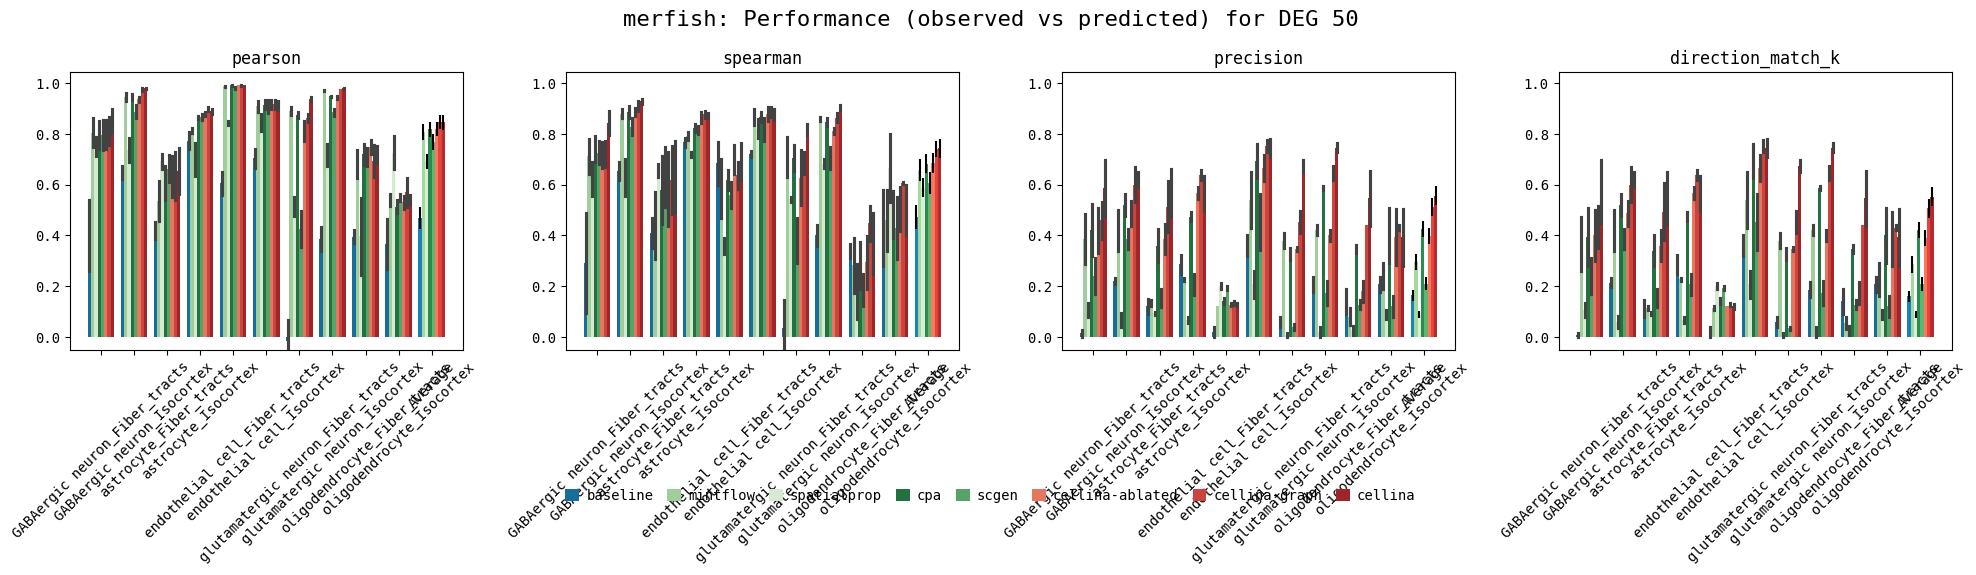

In [49]:
metrics = ["pearson", "spearman", "precision", "direction_match_k"]
plot_model_comparison(
    dataset_name,
    combined_df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name="ood_summary_correlations_200"
)

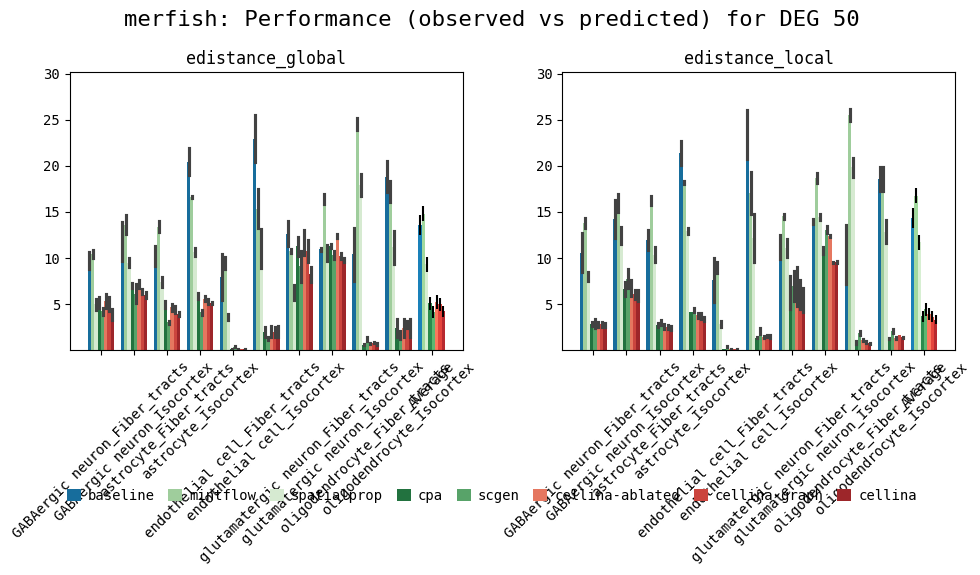

In [50]:
metrics = ["edistance_global", "edistance_local"]
plot_model_comparison(
    dataset_name,
    combined_df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name="ood_summary_correlations_200"
)

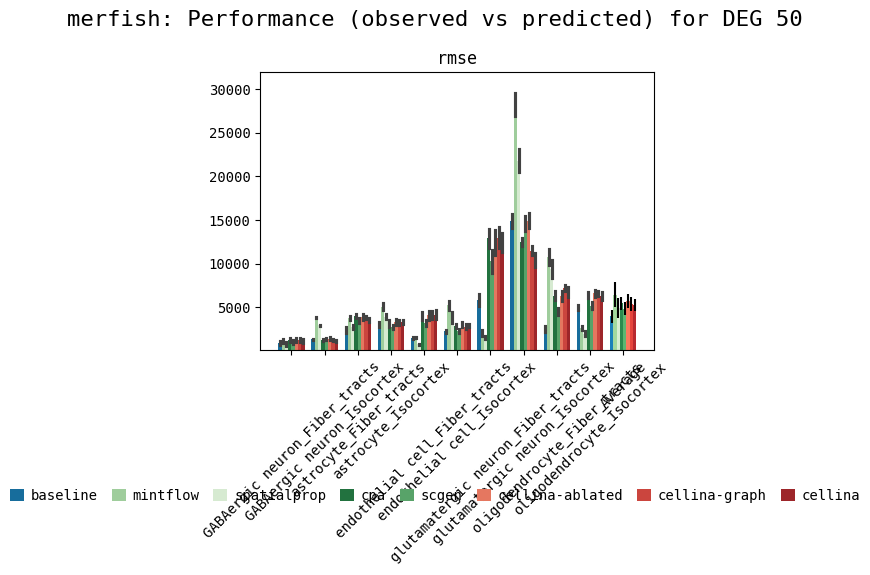

In [51]:
metrics = ["rmse"]
plot_model_comparison(
    dataset_name,
    combined_df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name="ood_summary_correlations_200"
)

In [ ]:
combined_df.to_csv(f"../results/loo_summary_{dataset_name}_DEG_{n_deg}.csv", index=False)